action_recognition_labels.zip

In [2]:
import os

url = 'https://data.4tu.nl/file/b008dd74-020d-4ea4-a8ba-7bb60769d224/778d7d5f-6631-4cb6-9451-f88c574c7991'

os.system(f'curl -L --retry 3 -o /kaggle/working/action_recognition_labels.zip "{url}"')
os.system('unzip -q /kaggle/working/action_recognition_labels.zip -d /kaggle/working/labels/')
os.system('rm /kaggle/working/action_recognition_labels.zip')

# Voir ce qu'il contient
for root, dirs, files in os.walk('/kaggle/working/labels/'):
    for f in files:
        print(os.path.join(root, f))

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

/kaggle/working/labels/val.csv
/kaggle/working/labels/test.csv
/kaggle/working/labels/train.csv


100 67816  100 67816    0     0  37972      0  0:00:01  0:00:01 --:--:-- 37992


In [9]:
import os
import numpy as np
import pandas as pd
from collections import Counter

# ── Chemins ──────────────────────────────────────────────
TRAIN_FEAT_DIR = '/kaggle/input/hibabou/datasets/industrial/data/train/'
VAL_FEAT_DIR   = '/kaggle/input/hibabou/datasets/industrial/data/val/'
TRAIN_CSV      = '/kaggle/working/labels/train.csv'
VAL_CSV        = '/kaggle/working/labels/val.csv'
FEAT_DIM       = 2304
MIN_SAMPLES    = 5

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

print(f'Train CSV : {len(train_df)} lignes | colonnes : {list(train_df.columns)}')
print(f'Val   CSV : {len(val_df)} lignes')
print(f'\nAperçu train :')
print(train_df.head(10))


Train CSV : 3666 lignes | colonnes : ['01_assy_0_1', '0', 'take_short_brace', '000028.jpg', '000040.jpg']
Val   CSV : 1927 lignes

Aperçu train :
   01_assy_0_1   0   take_short_brace  000028.jpg  000040.jpg
0  01_assy_0_1  30    fit_short_brace  000040.jpg  000055.jpg
1  01_assy_0_1   0   take_short_brace  000059.jpg  000063.jpg
2  01_assy_0_1  30    fit_short_brace  000063.jpg  000073.jpg
3  01_assy_0_1   1      align_objects  000072.jpg  000084.jpg
4  01_assy_0_1   2     take_pin_short  000089.jpg  000099.jpg
5  01_assy_0_1   1      align_objects  000100.jpg  000110.jpg
6  01_assy_0_1   3     plug_short_pin  000102.jpg  000120.jpg
7  01_assy_0_1   4  take_tooth_washer  000136.jpg  000143.jpg
8  01_assy_0_1  31   fit_tooth_washer  000143.jpg  000150.jpg
9  01_assy_0_1   5           take_nut  000152.jpg  000166.jpg


In [10]:
col_names = ['recording', 'action_id', 'action_name', 'frame_start', 'frame_end']

train_df = pd.read_csv(TRAIN_CSV, header=None, names=col_names, sep=',')
val_df   = pd.read_csv(VAL_CSV,   header=None, names=col_names, sep=',')

# Convertir frame_start/end en int (enlever .jpg)
train_df['frame_start'] = train_df['frame_start'].str.replace('.jpg', '').astype(int)
train_df['frame_end']   = train_df['frame_end'].str.replace('.jpg', '').astype(int)
val_df['frame_start']   = val_df['frame_start'].str.replace('.jpg', '').astype(int)
val_df['frame_end']     = val_df['frame_end'].str.replace('.jpg', '').astype(int)

print(f'Train CSV : {len(train_df)} lignes')
print(f'Val   CSV : {len(val_df)} lignes')
print(f'\nAperçu :')
print(train_df.head())
print(f'\nClasses uniques train : {train_df["action_id"].nunique()}')
print(f'Classes uniques val   : {val_df["action_id"].nunique()}')
print(f'Recordings train      : {train_df["recording"].nunique()}')
print(f'Recordings val        : {val_df["recording"].nunique()}')

Train CSV : 3667 lignes
Val   CSV : 1928 lignes

Aperçu :
     recording  action_id       action_name  frame_start  frame_end
0  01_assy_0_1          0  take_short_brace           28         40
1  01_assy_0_1         30   fit_short_brace           40         55
2  01_assy_0_1          0  take_short_brace           59         63
3  01_assy_0_1         30   fit_short_brace           63         73
4  01_assy_0_1          1     align_objects           72         84

Classes uniques train : 72
Classes uniques val   : 65
Recordings train      : 36
Recordings val        : 16


In [11]:
train_classes = set(train_df['action_id'].unique())
val_classes   = set(val_df['action_id'].unique())

only_in_train = train_classes - val_classes
only_in_val   = val_classes - train_classes

print(f'Classes seulement dans train ({len(only_in_train)}) :')
for c in sorted(only_in_train):
    name  = train_df[train_df['action_id'] == c]['action_name'].iloc[0]
    count = (train_df['action_id'] == c).sum()
    print(f'  id={c:3d} | {name:30s} | n={count}')

print(f'\nClasses seulement dans val ({len(only_in_val)}) :')
for c in sorted(only_in_val):
    name  = val_df[val_df['action_id'] == c]['action_name'].iloc[0]
    count = (val_df['action_id'] == c).sum()
    print(f'  id={c:3d} | {name:30s} | n={count}')

print(f'\nClasses rares dans train (< {MIN_SAMPLES}) :')
train_counts = train_df['action_id'].value_counts()
rare = train_counts[train_counts < MIN_SAMPLES]
for c, n in rare.items():
    name = train_df[train_df['action_id'] == c]['action_name'].iloc[0]
    print(f'  id={c:3d} | {name:30s} | n={n}')

Classes seulement dans train (9) :
  id= 25 | plug_partial_model             | n=3
  id= 28 | plug_wheel                     | n=2
  id= 49 | pull_partial_model             | n=4
  id= 52 | put_short_brace                | n=12
  id= 59 | put_wing_beam                  | n=6
  id= 64 | fit_partial_model              | n=1
  id= 70 | pull_pin_long                  | n=2
  id= 73 | tighten_tooth_washer           | n=1
  id= 74 | loosen_tooth_washer            | n=1

Classes seulement dans val (2) :
  id= 66 | plug_small_screw_pin           | n=4
  id= 72 | pull_small_screw_pin           | n=1

Classes rares dans train (< 5) :
  id= 51 | check_partial_model            | n=4
  id= 49 | pull_partial_model             | n=4
  id= 25 | plug_partial_model             | n=3
  id= 12 | put_instruction                | n=3
  id= 11 | take_instruction               | n=2
  id= 62 | put_acorn_nut                  | n=2
  id= 67 | put_small_screw_pin            | n=2
  id= 28 | plug_wheel           

In [13]:
# ── Analyse nature des classes rares ─────────────────────
train_counts = train_df['action_id'].value_counts()
rare_ids     = set(train_counts[train_counts < MIN_SAMPLES].index)
only_in_train = set(train_df['action_id'].unique()) - set(val_df['action_id'].unique())
only_in_val   = set(val_df['action_id'].unique())   - set(train_df['action_id'].unique())

print("=== CLASSES SEULEMENT DANS TRAIN ===")
for c in sorted(only_in_train):
    name  = train_df[train_df['action_id'] == c]['action_name'].iloc[0]
    count = (train_df['action_id'] == c).sum()
    recs  = train_df[train_df['action_id'] == c]['recording'].unique()
    print(f'  id={c:3d} | n={count:3d} | recs={list(recs)} | {name}')

print("\n=== CLASSES RARES (< 5) ===")
for c in sorted(rare_ids):
    name  = train_df[train_df['action_id'] == c]['action_name'].iloc[0]
    count = (train_df['action_id'] == c).sum()
    recs  = train_df[train_df['action_id'] == c]['recording'].unique()
    sub   = train_df[train_df['action_id'] == c]
    duree = (sub['frame_end'] - sub['frame_start']).mean()
    print(f'  id={c:3d} | n={count} | duree_moy={duree:.0f}f | recs={list(recs)} | {name}')

print("\n=== CLASSES SEULEMENT DANS VAL ===")
for c in sorted(only_in_val):
    name     = val_df[val_df['action_id'] == c]['action_name'].iloc[0]
    count    = (val_df['action_id'] == c).sum()
    recs     = val_df[val_df['action_id'] == c]['recording'].unique()
    duree    = (val_df[val_df['action_id'] == c]['frame_end'] - 
                val_df[val_df['action_id'] == c]['frame_start']).mean()
    print(f'  id={c:3d} | n={count} | duree_moy={duree:.0f}f | recs={list(recs)} | {name}')

print("\n=== PATTERN NOMS ===")
all_actions = pd.concat([train_df, val_df])[['action_id','action_name']].drop_duplicates()
all_actions['prefix'] = all_actions['action_name'].str.extract(r'^(\w+)_')
print(all_actions.groupby('prefix')['action_id'].count().sort_values(ascending=False))

=== CLASSES SEULEMENT DANS TRAIN ===
  id= 25 | n=  3 | recs=['02_assy_1_2', '07_assy_2_3', '07_main_0_1'] | plug_partial_model
  id= 28 | n=  2 | recs=['07_assy_2_3', '11_assy_0_1'] | plug_wheel
  id= 49 | n=  4 | recs=['02_assy_1_2', '16_assy_0_1'] | pull_partial_model
  id= 52 | n= 12 | recs=['02_main_0_1', '07_assy_2_3', '07_main_0_1', '16_main_0_1', '16_main_3_3', '22_assy_0_1', '22_assy_2_3'] | put_short_brace
  id= 59 | n=  6 | recs=['02_assy_1_2', '06_assy_1_4', '11_assy_3_3', '16_assy_0_1', '22_assy_0_1', '22_assy_2_3'] | put_wing_beam
  id= 64 | n=  1 | recs=['04_main_0_1'] | fit_partial_model
  id= 70 | n=  2 | recs=['06_assy_1_4', '27_assy_0_1'] | pull_pin_long
  id= 73 | n=  1 | recs=['16_assy_0_1'] | tighten_tooth_washer
  id= 74 | n=  1 | recs=['16_assy_0_1'] | loosen_tooth_washer

=== CLASSES RARES (< 5) ===
  id= 11 | n=2 | duree_moy=11f | recs=['01_assy_0_1', '06_assy_1_4'] | take_instruction
  id= 12 | n=3 | duree_moy=10f | recs=['01_assy_0_1', '01_assy_1_1', '01_mai

pattern detecte
take_X  →  manipuler X (prise)
put_X   →  poser X
fit_X   →  assembler X
plug_X  →  insérer X
pull_X  →  retirer X
tighten_X / loosen_X  →  serrer/desserrer X
check_X →  vérifier X

In [14]:
# Verbes présents dans train
all_actions = train_df[['action_id','action_name']].drop_duplicates()
all_actions['verb'] = all_actions['action_name'].str.split('_').str[0]

print("=== VERBES DANS TRAIN ===")
for verb, group in all_actions.groupby('verb'):
    ids = sorted(group['action_id'].tolist())
    counts = [train_counts.get(i, 0) for i in ids]
    print(f'  {verb:12s} : ids={ids} | counts={counts}')

print("\n=== VERBES DANS VAL ===")
val_actions = val_df[['action_id','action_name']].drop_duplicates()
val_actions['verb'] = val_actions['action_name'].str.split('_').str[0]
for verb, group in val_actions.groupby('verb'):
    ids = sorted(group['action_id'].tolist())
    print(f'  {verb:12s} : ids={ids}')

=== VERBES DANS TRAIN ===
  align        : ids=[1] | counts=[np.int64(212)]
  browse       : ids=[29] | counts=[np.int64(48)]
  check        : ids=[7, 51] | counts=[np.int64(404), np.int64(4)]
  fit          : ids=[30, 31, 32, 33, 34, 50, 53, 55, 56, 64, 68, 69] | counts=[np.int64(52), np.int64(158), np.int64(121), np.int64(7), np.int64(163), np.int64(62), np.int64(6), np.int64(33), np.int64(15), np.int64(1), np.int64(12), np.int64(8)]
  loosen       : ids=[39, 63, 74] | counts=[np.int64(52), np.int64(1), np.int64(1)]
  plug         : ids=[3, 16, 22, 25, 26, 28, 71] | counts=[np.int64(104), np.int64(26), np.int64(21), np.int64(3), np.int64(29), np.int64(2), np.int64(80)]
  pull         : ids=[38, 41, 46, 49, 58, 61, 70] | counts=[np.int64(5), np.int64(18), np.int64(39), np.int64(4), np.int64(14), np.int64(8), np.int64(2)]
  put          : ids=[12, 14, 24, 35, 36, 40, 42, 44, 45, 47, 48, 52, 54, 57, 59, 60, 62, 67] | counts=[np.int64(3), np.int64(5), np.int64(7), np.int64(5), np.int64(2

Classes rares → fusionner avec parent SÉMANTIQUE (même verbe, bien représenté)
Classes rares → fusionner avec parent SÉMANTIQUE (même verbe, bien représenté)

take_instruction (11) → browse (29)  ✅ n=48
put_instruction  (12) → browse (29)  ✅ n=48
check_partial    (51) → check  (7)   ✅ n=404
plug_partial     (25) → plug   (3)   ✅ n=104
plug_wheel       (28) → plug   (3)   ✅ n=104
pull_partial     (49) → pull   (46)  ✅ n=39
fit_partial      (64) → fit    (30)  ✅ n=52
put_wing_beam    (59) → put    (44)  ✅ n=118
put_short_brace  (52) → put    (44)  ✅ n=118 (n=12, pas si rare)
pull_pin_long    (70) → pull   (46)  ✅ n=39
tighten_tooth    (73) → tighten(6)   ✅ n=178
loosen_tooth     (74) → loosen (39)  ✅ n=52
put_acorn_nut    (62) → put    (44)  ✅ n=118
loosen_acorn_nut (63) → loosen (39)  ✅ n=52
take_small_screw (65) → take   (2)   ✅ n=101
put_small_screw  (67) → put    (44)  ✅ n=118

# Val only — même logique
plug_small_screw (66) → plug   (3)   ✅ n=104
pull_small_screw (72) → pull   (46)  ✅ n=39

take_instruction (11) → browse (29)  ✅ n=48
put_instruction  (12) → browse (29)  ✅ n=48
check_partial    (51) → check  (7)   ✅ n=404
plug_partial     (25) → plug   (3)   ✅ n=104
plug_wheel       (28) → plug   (3)   ✅ n=104
pull_partial     (49) → pull   (46)  ✅ n=39
fit_partial      (64) → fit    (30)  ✅ n=52
put_wing_beam    (59) → put    (44)  ✅ n=118
put_short_brace  (52) → put    (44)  ✅ n=118 (n=12, pas si rare)
pull_pin_long    (70) → pull   (46)  ✅ n=39
tighten_tooth    (73) → tighten(6)   ✅ n=178
loosen_tooth     (74) → loosen (39)  ✅ n=52
put_acorn_nut    (62) → put    (44)  ✅ n=118
loosen_acorn_nut (63) → loosen (39)  ✅ n=52
take_small_screw (65) → take   (2)   ✅ n=101
put_small_screw  (67) → put    (44)  ✅ n=118

# Val only — même logique
plug_small_screw (66) → plug   (3)   ✅ n=104
pull_small_screw (72) → pull   (46)  ✅ n=39

Résumé : ne pas merger, évaluer honnêtement, laisser Mahalanobis gérer les anomalies. C'est plus propre et plus fidèle à la réalité industrielle.

In [15]:
# Chercher fichier erreurs dans les labels
import os

for root, dirs, files in os.walk('/kaggle/working/labels/'):
    for f in files:
        print(os.path.join(root, f))

# Lire test.csv aussi pour voir structure
test_df = pd.read_csv('/kaggle/working/labels/test.csv', 
                       header=None, 
                       names=['recording','action_id','action_name','frame_start','frame_end'])
print(f'\nTest CSV : {len(test_df)} lignes')
print(test_df.head(10))
print(f'\nClasses test : {test_df["action_id"].nunique()}')

/kaggle/working/labels/val.csv
/kaggle/working/labels/test.csv
/kaggle/working/labels/train.csv

Test CSV : 3678 lignes
     recording  action_id         action_name frame_start   frame_end
0  03_assy_0_1          8  take_partial_model  000027.jpg  000039.jpg
1  03_assy_0_1         44   put_partial_model  000041.jpg  000050.jpg
2  03_assy_0_1          9     take_long_brace  000052.jpg  000063.jpg
3  03_assy_0_1          9     take_long_brace  000072.jpg  000087.jpg
4  03_assy_0_1          1       align_objects  000175.jpg  000234.jpg
5  03_assy_0_1          2      take_pin_short  000255.jpg  000265.jpg
6  03_assy_0_1          4   take_tooth_washer  000349.jpg  000359.jpg
7  03_assy_0_1         31    fit_tooth_washer  000361.jpg  000378.jpg
8  03_assy_0_1          5            take_nut  000384.jpg  000393.jpg
9  03_assy_0_1         34             fit_nut  000394.jpg  000438.jpg

Classes test : 68


telechargement erreur

In [19]:
# Re-télécharger et inspecter le vrai contenu du zip labels
import os

url = 'https://data.4tu.nl/file/b008dd74-020d-4ea4-a8ba-7bb60769d224/778d7d5f-6631-4cb6-9451-f88c574c7991'
os.system(f'curl -L -o /kaggle/working/labels_full.zip "{url}"')

# Lister tout le contenu sans extraire
os.system('unzip -l /kaggle/working/labels_full.zip | head -50')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
 47 67816   47 32489    0     0  24968      0  0:00:02  0:00:01  0:00:01 24953

Archive:  /kaggle/working/labels_full.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   192153  2023-06-24 23:30   test.csv
   191368  2023-06-24 23:31   train.csv
   100787  2023-06-24 23:30   val.csv
---------                     -------
   484308                     3 files


100 67816  100 67816    0     0  43416      0  0:00:01  0:00:01 --:--:-- 43416


0

In [25]:
import numpy as np
import glob
import pickle
from sklearn.preprocessing import StandardScaler

train_files = sorted(glob.glob('/kaggle/input/datasets/hibabou/industrial/data/train/*.npy'))
val_files   = sorted(glob.glob('/kaggle/input/datasets/hibabou/industrial/data/val/*.npy'))

# Charger tout train
X_train = np.vstack([np.load(f) for f in train_files])
X_val   = np.vstack([np.load(f) for f in val_files])

print(f'X_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'\nAvant normalisation :')
print(f'  Train — mean={X_train.mean():.4f} | std={X_train.std():.4f}')
print(f'  Val   — mean={X_val.mean():.4f}   | std={X_val.std():.4f}')
print(f'  NaN train : {np.isnan(X_train).sum()} | Inf : {np.isinf(X_train).sum()}')
print(f'  NaN val   : {np.isnan(X_val).sum()}   | Inf : {np.isinf(X_val).sum()}')

# Fit sur train uniquement
scaler = StandardScaler()
scaler.fit(X_train)

X_train_sc = scaler.transform(X_train)
X_val_sc   = scaler.transform(X_val)

print(f'\nAprès StandardScaler :')
print(f'  Train — mean={X_train_sc.mean():.4f} | std={X_train_sc.std():.4f}')
print(f'  Val   — mean={X_val_sc.mean():.4f}   | std={X_val_sc.std():.4f}')

# Sauvegarder scaler
with open('/kaggle/working/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('\n✅ Scaler sauvegardé')

X_train shape : (51064, 2304)
X_val   shape : (18824, 2304)

Avant normalisation :
  Train — mean=0.1889 | std=0.4081
  Val   — mean=0.1888   | std=0.4024
  NaN train : 0 | Inf : 0
  NaN val   : 0   | Inf : 0

Après StandardScaler :
  Train — mean=0.0000 | std=1.0000
  Val   — mean=-0.0025   | std=0.9838

✅ Scaler sauvegardé


Excellent — normalisation parfaite ✅ :

NaN=0, Inf=0 ✅
Train après scaling : mean=0.0, std=1.0 ✅
Val après scaling : mean=-0.0025, std=0.9838 ✅ — très proche de train, pas de distribution shift

In [26]:
# ── Point 5 : Features mortes + PCA ─────────────────────
from sklearn.decomposition import PCA

feat_stds = X_train.std(axis=0)
dead = (feat_stds < 1e-6).sum()
print(f'Features mortes : {dead}/{FEAT_DIM}')
print(f'Std features — min={feat_stds.min():.4f} | mean={feat_stds.mean():.4f} | max={feat_stds.max():.4f}')

pca = PCA(n_components=200)
pca.fit(X_train_sc)
cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f'\nPCA variance explained :')
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= thresh) + 1
    print(f'  {thresh*100:.0f}% → {n} composantes')

Features mortes : 0/2304
Std features — min=0.0011 | mean=0.3502 | max=1.7704

PCA variance explained :
  80% → 114 composantes
  90% → 1 composantes
  95% → 1 composantes
  99% → 1 composantes


In [27]:
# Debug PCA
print(f'explained_variance_ratio_ shape : {pca.explained_variance_ratio_.shape}')
print(f'Premières 10 valeurs : {pca.explained_variance_ratio_[:10]}')
print(f'Somme totale : {pca.explained_variance_ratio_.sum():.4f}')
print(f'cumvar[0]={cumvar[0]:.4f} | cumvar[1]={cumvar[1]:.4f} | cumvar[10]={cumvar[10]:.4f}')

explained_variance_ratio_ shape : (200,)
Premières 10 valeurs : [0.08683372 0.04890544 0.04241554 0.0360242  0.03474218 0.03092295
 0.02897233 0.0271515  0.02455611 0.02262556]
Somme totale : 0.8572
cumvar[0]=0.0868 | cumvar[1]=0.1357 | cumvar[10]=0.4028


80% → 114 composantes  ✅ correct
90% → non atteint dans 200 composantes (somme totale = 85.7%)
95% → non atteint
99% → non atteint
Ce qui signifie : 2304 features SlowFast sont très distribuées — pas de dominance d'une seule composante. C'est une bonne chose


In [28]:
# Fix PCA avec plus de composantes
pca2 = PCA(n_components=500)
pca2.fit(X_train_sc)
cumvar2 = np.cumsum(pca2.explained_variance_ratio_)

print(f'PCA variance explained :')
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumvar2 >= thresh) + 1
    if cumvar2[n-1] >= thresh:
        print(f'  {thresh*100:.0f}% → {n} composantes')
    else:
        print(f'  {thresh*100:.0f}% → non atteint ({cumvar2[-1]*100:.1f}% max avec 500)')

PCA variance explained :
  80% → 114 composantes
  90% → 337 composantes
  95% → non atteint (92.7% max avec 500)
  99% → non atteint (92.7% max avec 500)


95% variance → besoin de 500+ composantes
               réduction 2304 → 500 = gain marginal
               perte d'information garantie

BiGRU avec dropout va :
  → apprendre à ignorer les features redondantes
  → gérer la haute dimensionnalité naturellement
  → être plus robuste qu'un PCA figé

✅ Normalisation  → StandardScaler fit sur train uniquement
✅ PCA            → NON, garder 2304d
✅ Lissage        → NON, BiGRU apprend cohérence temporelle
✅ Features mortes → 0/2304, aucune à supprimer

In [29]:
# Class weights + segment stats
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(train_df['action_id'].unique()))
weights = compute_class_weight('balanced', classes=classes, y=train_df['action_id'].values)
class_weights = dict(zip(classes.tolist(), weights.tolist()))

print('=== CLASS WEIGHTS (top 10) ===')
for cls, w in sorted(class_weights.items(), key=lambda x: x[1], reverse=True)[:10]:
    name = train_df[train_df['action_id'] == cls]['action_name'].iloc[0]
    n    = (train_df['action_id'] == cls).sum()
    print(f'  id={cls:3d} | w={w:7.3f} | n={n:4d} | {name}')

train_df['duration'] = train_df['frame_end'] - train_df['frame_start']
print(f'\n=== SEGMENT STATS ===')
print(f'  Durée moyenne  : {train_df["duration"].mean():.1f} frames')
print(f'  Durée médiane  : {train_df["duration"].median():.1f} frames')
print(f'  Durée min      : {train_df["duration"].min()} frames')
print(f'  Durée max      : {train_df["duration"].max()} frames')

=== CLASS WEIGHTS (top 10) ===
  id= 63 | w= 50.931 | n=   1 | loosen_acorn_nut
  id= 64 | w= 50.931 | n=   1 | fit_partial_model
  id= 65 | w= 50.931 | n=   1 | take_small_screw_pin
  id= 73 | w= 50.931 | n=   1 | tighten_tooth_washer
  id= 74 | w= 50.931 | n=   1 | loosen_tooth_washer
  id= 11 | w= 25.465 | n=   2 | take_instruction
  id= 28 | w= 25.465 | n=   2 | plug_wheel
  id= 62 | w= 25.465 | n=   2 | put_acorn_nut
  id= 67 | w= 25.465 | n=   2 | put_small_screw_pin
  id= 70 | w= 25.465 | n=   2 | pull_pin_long

=== SEGMENT STATS ===
  Durée moyenne  : 17.9 frames
  Durée médiane  : 14.0 frames
  Durée min      : 2 frames
  Durée max      : 253 frames


3 problèmes visibles
Classes n=1 → weight=50.93 → pendant training BiGRU
va sur-pondérer massivement ces classes
→ gradients instables → loss explose
→ modèle biaisé vers classes n=1

CLIP_LEN=32, STRIDE=16
Un segment de 2 frames → 0 clips extraits
→ ces segments sont invisibles pour le BiGRU
→ labels présents dans CSV mais pas dans features
→ risque misalignment

253 frames / STRIDE=16 = ~15 clips pour 1 segment
→ forte sur-représentation de ce segment
→ déséquilibre temporel

In [31]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

CLIP_LEN = 32
STRIDE   = 16

# Segments trop courts
train_df['duration'] = train_df['frame_end'] - train_df['frame_start']
short = train_df[train_df['duration'] < CLIP_LEN]
print(f'Segments < {CLIP_LEN} frames : {len(short)}')
print(short[['recording','action_id','action_name','duration']].to_string())

# Cap class weights à 10
classes = np.array(sorted(train_df['action_id'].unique()))
weights = compute_class_weight('balanced', classes=classes, y=train_df['action_id'].values)
weights = np.clip(weights, 0, 10.0)
cw_tensor = torch.tensor(weights, dtype=torch.float32)

print(f'\nClass weights après cap :')
print(f'  min={weights.min():.3f} | max={weights.max():.3f} | mean={weights.mean():.3f}')
print(f'\nTop 10 après cap :')
for cls, w in sorted(zip(classes.tolist(), weights.tolist()), key=lambda x: x[1], reverse=True)[:10]:
    name = train_df[train_df['action_id'] == cls]['action_name'].iloc[0]
    n    = (train_df['action_id'] == cls).sum()
    print(f'  id={cls:3d} | w={w:.3f} | n={n:4d} | {name}')

Segments < 32 frames : 3296
        recording  action_id           action_name  duration
0     01_assy_0_1          0      take_short_brace        12
1     01_assy_0_1         30       fit_short_brace        15
2     01_assy_0_1          0      take_short_brace         4
3     01_assy_0_1         30       fit_short_brace        10
4     01_assy_0_1          1         align_objects        12
5     01_assy_0_1          2        take_pin_short        10
6     01_assy_0_1          1         align_objects        10
7     01_assy_0_1          3        plug_short_pin        18
8     01_assy_0_1          4     take_tooth_washer         7
9     01_assy_0_1         31      fit_tooth_washer         7
10    01_assy_0_1          5              take_nut        14
11    01_assy_0_1         34               fit_nut         8
12    01_assy_0_1          6           tighten_nut         7
13    01_assy_0_1          6           tighten_nut        11
14    01_assy_0_1          7     check_instruction       

Les vrais problèmes identifiés :
3296 segments < 32 frames — c'est 90% du dataset. Ce n'est pas un bug, c'est la nature du dataset : les actions industrielles sont courtes (médiane=14 frames).
Conclusion : CLIP_LEN=32 est trop grand. Il faut l'adapter aux données.

In [32]:
durations = train_df['duration'].values
print(f'% segments >= 8  frames : {(durations >= 8).mean():.1%}')
print(f'% segments >= 16 frames : {(durations >= 16).mean():.1%}')
print(f'% segments >= 32 frames : {(durations >= 32).mean():.1%}')

for p in [25, 50, 75, 90, 95]:
    print(f'  p{p} : {np.percentile(durations, p):.0f} frames')

% segments >= 8  frames : 90.6%
% segments >= 16 frames : 43.1%
% segments >= 32 frames : 10.1%
  p25 : 10 frames
  p50 : 14 frames
  p75 : 21 frames
  p90 : 32 frames
  p95 : 40 frames


In [33]:
# Comparer durée vidéo complète vs durée segments
print("=== DURÉE TOTALE PAR RECORDING ===")
for rec in train_df['recording'].unique()[:5]:
    sub = train_df[train_df['recording'] == rec]
    f_start = sub['frame_start'].min()
    f_end   = sub['frame_end'].max()
    total_frames = f_end - f_start
    n_clips_possible = max(0, (total_frames - 32) // 16 + 1)
    print(f'  {rec} | total={total_frames}f | clips_possible={n_clips_possible}')

# Charger la feature correspondante
import glob
for rec in train_df['recording'].unique()[:5]:
    pattern = f'{TRAIN_FEAT_DIR}*{rec}*.npy'
    files = glob.glob(pattern)
    if files:
        arr = np.load(files[0])
        print(f'  {rec} | feat_shape={arr.shape}')

=== DURÉE TOTALE PAR RECORDING ===
  01_assy_0_1 | total=1789f | clips_possible=110
  01_assy_1_1 | total=2085f | clips_possible=129
  01_main_0_1 | total=1282f | clips_possible=79
  02_assy_0_1 | total=3852f | clips_possible=239
  02_assy_1_2 | total=3563f | clips_possible=221


In [34]:
import glob

print("=== COMPARAISON clips_possible vs feat_shape ===")
for rec in train_df['recording'].unique()[:5]:
    sub = train_df[train_df['recording'] == rec]
    f_start = sub['frame_start'].min()
    f_end   = sub['frame_end'].max()
    total_frames = f_end - f_start
    n_clips = max(0, (total_frames - 32) // 16 + 1)
    
    # Chercher le fichier feature
    matches = []
    for prefix in ['train_p1_', 'train_p2_', 'train_p3_', 'train_p4_']:
        pattern = f'{TRAIN_FEAT_DIR}{prefix}{rec}_features.npy'
        matches += glob.glob(pattern)
    
    if matches:
        arr = np.load(matches[0])
        ratio = arr.shape[0] / n_clips if n_clips > 0 else 0
        status = '✅' if 0.8 <= ratio <= 1.2 else '⚠️'
        print(f'  {rec} | clips={n_clips} | feat={arr.shape[0]} | ratio={ratio:.2f} {status}')
    else:
        print(f'  {rec} | clips={n_clips} | feat=NOT FOUND')

=== COMPARAISON clips_possible vs feat_shape ===
  01_assy_0_1 | clips=110 | feat=NOT FOUND
  01_assy_1_1 | clips=129 | feat=NOT FOUND
  01_main_0_1 | clips=79 | feat=NOT FOUND
  02_assy_0_1 | clips=239 | feat=NOT FOUND
  02_assy_1_2 | clips=221 | feat=NOT FOUND


In [36]:
import os
import glob

TRAIN_FEAT_DIR = '/kaggle/input/datasets/hibabou/industrial/data/train/'
VAL_FEAT_DIR   = '/kaggle/input/datasets/hibabou/industrial/data/val/'

# Voir les vrais noms des fichiers
files = os.listdir(TRAIN_FEAT_DIR)
print("Premiers fichiers :")
for f in sorted(files)[:10]:
    print(f'  {f}')

print(f'\nPremiers recordings CSV :')
for r in train_df['recording'].unique()[:5]:
    print(f'  {r}')

Premiers fichiers :
  train_p1_01_assy_0_1_features.npy
  train_p1_01_assy_1_1_features.npy
  train_p1_01_main_0_1_features.npy
  train_p1_02_assy_0_1_features.npy
  train_p1_02_assy_1_2_features.npy
  train_p1_02_main_0_1_features.npy
  train_p1_04_assy_0_1_features.npy
  train_p1_04_assy_2_1_features.npy
  train_p1_04_main_0_1_features.npy
  train_p2_06_assy_0_1_features.npy

Premiers recordings CSV :
  01_assy_0_1
  01_assy_1_1
  01_main_0_1
  02_assy_0_1
  02_assy_1_2


In [37]:
import re

# Construire mapping recording → fichier feature
feat_files = os.listdir(TRAIN_FEAT_DIR)
rec_to_file = {}
for f in feat_files:
    # Extraire recording name en supprimant préfixe train_pX_ et suffixe _features.npy
    rec = re.sub(r'^train_p\d+_', '', f).replace('_features.npy', '')
    rec_to_file[rec] = os.path.join(TRAIN_FEAT_DIR, f)

print(f'Recordings mappés : {len(rec_to_file)}')

# Comparaison clips vs features
print("\n=== COMPARAISON clips_possible vs feat_shape ===")
for rec in train_df['recording'].unique()[:5]:
    sub = train_df[train_df['recording'] == rec]
    f_start = sub['frame_start'].min()
    f_end   = sub['frame_end'].max()
    total_frames = f_end - f_start
    n_clips = max(0, (total_frames - 32) // 16 + 1)

    if rec in rec_to_file:
        arr   = np.load(rec_to_file[rec])
        ratio = arr.shape[0] / n_clips if n_clips > 0 else 0
        status = '✅' if 0.8 <= ratio <= 1.2 else '⚠️'
        print(f'  {rec} | clips={n_clips} | feat={arr.shape[0]} | ratio={ratio:.2f} {status}')
    else:
        print(f'  {rec} | clips={n_clips} | feat=NOT FOUND ❌')

Recordings mappés : 36

=== COMPARAISON clips_possible vs feat_shape ===
  01_assy_0_1 | clips=110 | feat=1816 | ratio=16.51 ⚠️
  01_assy_1_1 | clips=129 | feat=2144 | ratio=16.62 ⚠️
  01_main_0_1 | clips=79 | feat=1336 | ratio=16.91 ⚠️
  02_assy_0_1 | clips=239 | feat=3920 | ratio=16.40 ⚠️
  02_assy_1_2 | clips=221 | feat=3632 | ratio=16.43 ⚠️


In [38]:
# Si STRIDE=1 et CLIP_LEN=32
for rec in train_df['recording'].unique()[:3]:
    sub = train_df[train_df['recording'] == rec]
    total_frames = sub['frame_end'].max() - sub['frame_start'].min()
    
    clips_stride1  = max(0, total_frames - 32 + 1)
    clips_stride16 = max(0, (total_frames - 32) // 16 + 1)
    arr = np.load(rec_to_file[rec])
    
    print(f'{rec} | feat={arr.shape[0]} | stride=1→{clips_stride1} | stride=16→{clips_stride16}')

01_assy_0_1 | feat=1816 | stride=1→1758 | stride=16→110
01_assy_1_1 | feat=2144 | stride=1→2054 | stride=16→129
01_main_0_1 | feat=1336 | stride=1→1251 | stride=16→79


In [39]:
# Calculer le vrai nb frames total de la vidéo (pas juste le segment)
# feat=1816, CLIP_LEN=32, chercher STRIDE qui donne 1816

for rec in train_df['recording'].unique()[:3]:
    arr = np.load(rec_to_file[rec])
    n_feat = arr.shape[0]
    
    # Trouver N_frames tel que (N - 32) // STRIDE + 1 = n_feat
    for stride in [1, 2, 4, 8, 16]:
        # N = (n_feat - 1) * stride + 32
        N = (n_feat - 1) * stride + 32
        print(f'  {rec} | feat={n_feat} | stride={stride} → N_frames={N}')
    print()

  01_assy_0_1 | feat=1816 | stride=1 → N_frames=1847
  01_assy_0_1 | feat=1816 | stride=2 → N_frames=3662
  01_assy_0_1 | feat=1816 | stride=4 → N_frames=7292
  01_assy_0_1 | feat=1816 | stride=8 → N_frames=14552
  01_assy_0_1 | feat=1816 | stride=16 → N_frames=29072

  01_assy_1_1 | feat=2144 | stride=1 → N_frames=2175
  01_assy_1_1 | feat=2144 | stride=2 → N_frames=4318
  01_assy_1_1 | feat=2144 | stride=4 → N_frames=8604
  01_assy_1_1 | feat=2144 | stride=8 → N_frames=17176
  01_assy_1_1 | feat=2144 | stride=16 → N_frames=34320

  01_main_0_1 | feat=1336 | stride=1 → N_frames=1367
  01_main_0_1 | feat=1336 | stride=2 → N_frames=2702
  01_main_0_1 | feat=1336 | stride=4 → N_frames=5372
  01_main_0_1 | feat=1336 | stride=8 → N_frames=10712
  01_main_0_1 | feat=1336 | stride=16 → N_frames=21392



In [40]:
# Vérifier nb frames JPG réels dans les vidéos
# On n'a plus les RGB mais on peut déduire depuis frame_end max dans CSV
for rec in train_df['recording'].unique()[:3]:
    sub = train_df[train_df['recording'] == rec]
    frame_end_max = sub['frame_end'].max()
    arr = np.load(rec_to_file[rec])
    n_feat = arr.shape[0]
    n_frames_stride1 = n_feat + 32 - 1
    
    print(f'{rec}')
    print(f'  frame_end_max CSV : {frame_end_max}')
    print(f'  N_frames stride=1 : {n_frames_stride1}')
    print(f'  Différence        : {abs(frame_end_max - n_frames_stride1)}')
    print()

01_assy_0_1
  frame_end_max CSV : 1817
  N_frames stride=1 : 1847
  Différence        : 30

01_assy_1_1
  frame_end_max CSV : 2112
  N_frames stride=1 : 2175
  Différence        : 63

01_main_0_1
  frame_end_max CSV : 1319
  N_frames stride=1 : 1367
  Différence        : 48



Features : 1 feature par frame (stride=1)
Labels   : frame_start → frame_end par segment
Mapping  : feature[i] correspond à frame i+16 (centre du clip)

In [41]:
# Fonction mapping label → indices features
def get_feature_indices(frame_start, frame_end, n_feats):
    # Chaque feature i correspond aux frames [i, i+32]
    # Centre du clip = i + 16
    # On prend les features dont le centre est dans [frame_start, frame_end]
    idx_start = max(0, frame_start - 16)
    idx_end   = min(n_feats, frame_end - 16)
    return idx_start, idx_end

# Test
for rec in train_df['recording'].unique()[:2]:
    arr  = np.load(rec_to_file[rec])
    sub  = train_df[train_df['recording'] == rec]
    print(f'\n{rec} | n_feats={arr.shape[0]}')
    for _, row in sub.iterrows():
        i0, i1 = get_feature_indices(row['frame_start'], row['frame_end'], arr.shape[0])
        n = i1 - i0
        print(f'  action={row["action_name"]:25s} | frames={row["frame_start"]}→{row["frame_end"]} | feat_idx={i0}→{i1} | n={n}')
        if n == 0:
            print(f'    ⚠️ SEGMENT VIDE')
        break  # juste 1 segment par recording pour test


01_assy_0_1 | n_feats=1816
  action=take_short_brace          | frames=28→40 | feat_idx=12→24 | n=12

01_assy_1_1 | n_feats=2144
  action=check_instruction         | frames=27→35 | feat_idx=11→19 | n=8


feat=1816 pour 01_assy_0_1
frame_end_max=1817

→ 1 feature ≈ 1 frame
→ features couvrent TOUTE la vidéo
→ chaque segment de 10-30 frames aura 10-30 features
→ même les segments courts (duration=2) auront ~2 features
Le problème des 3296 segments < 32 frames n'existe plus — c'était un faux problème basé sur l'hypothèse STRIDE=16. Avec STRIDE=1 :
Segment duration=10 frames → ~10 features ✅
Segment duration=5  frames → ~5  features ✅  
Segment duration=2  frames → ~2  features ✅ (petit mais présent)

In [42]:
def get_feature_indices(frame_start, frame_end, n_feats):
    idx_start = max(0, frame_start - 16)
    idx_end   = min(n_feats, frame_end - 16)
    return idx_start, idx_end

empty_segments = 0
total_segments = 0

for rec in train_df['recording'].unique():
    if rec not in rec_to_file:
        continue
    arr = np.load(rec_to_file[rec])
    sub = train_df[train_df['recording'] == rec]
    for _, row in sub.iterrows():
        i0, i1 = get_feature_indices(row['frame_start'], row['frame_end'], arr.shape[0])
        total_segments += 1
        if i1 - i0 <= 0:
            empty_segments += 1

print(f'Total segments    : {total_segments}')
print(f'Segments vides    : {empty_segments}')
print(f'Segments valides  : {total_segments - empty_segments}')
print(f'Coverage          : {(total_segments-empty_segments)/total_segments:.1%}')
print('✅ Pas de re-extraction' if empty_segments == 0 else f'⚠️ {empty_segments} segments vides')

Total segments    : 3667
Segments vides    : 1278
Segments valides  : 2389
Coverage          : 65.1%
⚠️ 1278 segments vides


1278 segments vides — le mapping est légèrement décalé. Ajustons l'offset :

In [43]:
# Tester différents offsets
for offset in [0, 8, 16, 32]:
    empty = 0
    for rec in train_df['recording'].unique():
        if rec not in rec_to_file:
            continue
        arr = np.load(rec_to_file[rec])
        sub = train_df[train_df['recording'] == rec]
        for _, row in sub.iterrows():
            i0 = max(0, row['frame_start'] - offset)
            i1 = min(arr.shape[0], row['frame_end'] - offset)
            if i1 - i0 <= 0:
                empty += 1
    print(f'offset={offset:2d} → segments vides={empty} | coverage={(3667-empty)/3667:.1%}')

offset= 0 → segments vides=1295 | coverage=64.7%
offset= 8 → segments vides=1287 | coverage=64.9%
offset=16 → segments vides=1278 | coverage=65.1%
offset=32 → segments vides=1254 | coverage=65.8%


In [44]:
# Analyse des segments vides
empty_analysis = []
for rec in train_df['recording'].unique():
    if rec not in rec_to_file:
        continue
    arr = np.load(rec_to_file[rec])
    sub = train_df[train_df['recording'] == rec]
    for _, row in sub.iterrows():
        i0 = max(0, row['frame_start'] - 16)
        i1 = min(arr.shape[0], row['frame_end'] - 16)
        duration = row['frame_end'] - row['frame_start']
        empty_analysis.append({
            'rec': rec,
            'action': row['action_name'],
            'duration': duration,
            'n_feats': i1 - i0,
            'empty': i1 - i0 <= 0
        })

df_analysis = pd.DataFrame(empty_analysis)

print("=== SEGMENTS VIDES ===")
print(f"Duration moyenne segments vides   : {df_analysis[df_analysis['empty']]['duration'].mean():.1f}")
print(f"Duration moyenne segments valides : {df_analysis[~df_analysis['empty']]['duration'].mean():.1f}")
print(f"\nDistribution duration segments vides :")
print(df_analysis[df_analysis['empty']]['duration'].value_counts().sort_index().head(20))

print(f"\n=== RECORDINGS SANS FEATURES ===")
recs_csv = set(train_df['recording'].unique())
recs_feat = set(rec_to_file.keys())
missing = recs_csv - recs_feat
print(f'Recordings dans CSV mais sans feature : {len(missing)}')
for r in sorted(missing):
    print(f'  {r}')

=== SEGMENTS VIDES ===
Duration moyenne segments vides   : 17.9
Duration moyenne segments valides : 17.9

Distribution duration segments vides :
duration
2      1
3      1
4      9
5     13
6     35
7     52
8     55
9     66
10    85
11    80
12    82
13    92
14    83
15    66
16    53
17    52
18    44
19    43
20    35
21    19
Name: count, dtype: int64

=== RECORDINGS SANS FEATURES ===
Recordings dans CSV mais sans feature : 0


Les segments vides ont la même durée moyenne que les valides — c'est un problème de recordings manquants dans certains batches. Vérifions :

In [45]:
# Identifier quels recordings ont des segments vides
print("=== RECORDINGS AVEC SEGMENTS VIDES ===")
empty_by_rec = df_analysis[df_analysis['empty']].groupby('rec').size().sort_values(ascending=False)
print(empty_by_rec)

print(f"\n=== RECORDINGS DANS FEATURES ===")
print(sorted(rec_to_file.keys()))

=== RECORDINGS AVEC SEGMENTS VIDES ===
rec
16_assy_0_1    87
07_assy_2_3    71
11_assy_0_1    69
22_assy_2_3    65
21_assy_0_1    63
16_main_0_1    62
06_assy_1_4    60
15_assy_0_1    60
27_assy_0_1    58
06_assy_0_1    55
11_assy_3_3    52
22_assy_0_1    51
25_assy_0_1    50
07_assy_0_1    46
15_main_3_1    40
25_main_0_1    40
16_main_3_3    36
06_main_0_1    35
27_main_0_1    35
27_main_1_3    35
27_main_3_1    35
25_assy_2_1    35
22_main_0_1    35
11_main_0_1    29
21_main_0_1    27
15_main_3_2    24
07_main_0_1    23
dtype: int64

=== RECORDINGS DANS FEATURES ===
['01_assy_0_1', '01_assy_1_1', '01_main_0_1', '02_assy_0_1', '02_assy_1_2', '02_main_0_1', '04_assy_0_1', '04_assy_2_1', '04_main_0_1', '06_assy_0_1', '06_assy_1_4', '06_main_0_1', '07_assy_0_1', '07_assy_2_3', '07_main_0_1', '11_assy_0_1', '11_assy_3_3', '11_main_0_1', '15_assy_0_1', '15_main_3_1', '15_main_3_2', '16_assy_0_1', '16_main_0_1', '16_main_3_3', '21_assy_0_1', '21_main_0_1', '22_assy_0_1', '22_assy_2_3', '22

Tous les recordings ont des features — le problème est différent. Les segments vides sont distribués sur tous les recordings. C'est un problème de frame numbering — les frames dans le CSV commencent à un numéro différent de 0.

In [46]:
# Vérifier le frame_start minimum par recording
print("=== FRAME START MIN PAR RECORDING ===")
for rec in sorted(rec_to_file.keys())[:5]:
    sub   = train_df[train_df['recording'] == rec]
    arr   = np.load(rec_to_file[rec])
    f_min = sub['frame_start'].min()
    f_max = sub['frame_end'].max()
    print(f'  {rec} | frame_min={f_min} | frame_max={f_max} | n_feats={arr.shape[0]}')
    
    # Tester mapping avec frame_start comme offset de base
    offset = f_min
    empty = 0
    for _, row in sub.iterrows():
        i0 = max(0, row['frame_start'] - offset)
        i1 = min(arr.shape[0], row['frame_end'] - offset)
        if i1 - i0 <= 0:
            empty += 1
    print(f'    offset={offset} → segments vides={empty}/{len(sub)}')

=== FRAME START MIN PAR RECORDING ===
  01_assy_0_1 | frame_min=28 | frame_max=1817 | n_feats=1816
    offset=28 → segments vides=0/105
  01_assy_1_1 | frame_min=27 | frame_max=2112 | n_feats=2144
    offset=27 → segments vides=0/125
  01_main_0_1 | frame_min=37 | frame_max=1319 | n_feats=1336
    offset=37 → segments vides=0/83
  02_assy_0_1 | frame_min=38 | frame_max=3890 | n_feats=3920
    offset=38 → segments vides=0/126
  02_assy_1_2 | frame_min=45 | frame_max=3608 | n_feats=3632
    offset=45 → segments vides=0/112


    offset=45 → segments vides=0/11220:06Claude responded: 0 segments vides avec offset=framemin ✅ — le fix est simple : utiliser framestart_min de chaque recording comme offset.0 segments vides avec offset=frame_min ✅ — le fix est simple : utiliser frame_start_min de chaque recording comme offset.

In [47]:
# Vérifier sur TOUS les recordings
total_empty = 0
total_segs  = 0

for rec in rec_to_file.keys():
    sub    = train_df[train_df['recording'] == rec]
    arr    = np.load(rec_to_file[rec])
    offset = sub['frame_start'].min()
    
    for _, row in sub.iterrows():
        i0 = max(0, row['frame_start'] - offset)
        i1 = min(arr.shape[0], row['frame_end'] - offset)
        total_segs += 1
        if i1 - i0 <= 0:
            total_empty += 1

print(f'Total segments  : {total_segs}')
print(f'Segments vides  : {total_empty}')
print(f'Coverage        : {(total_segs-total_empty)/total_segs:.1%}')
print('✅ Mapping parfait' if total_empty == 0 else f'⚠️ {total_empty} encore vides')

Total segments  : 3667
Segments vides  : 1239
Coverage        : 66.2%
⚠️ 1239 encore vides


In [48]:
# Trouver les recordings qui ont encore des vides
print("=== RECORDINGS AVEC VIDES APRÈS OFFSET FIX ===")
for rec in sorted(rec_to_file.keys()):
    sub    = train_df[train_df['recording'] == rec]
    arr    = np.load(rec_to_file[rec])
    offset = sub['frame_start'].min()
    
    empty = 0
    for _, row in sub.iterrows():
        i0 = max(0, row['frame_start'] - offset)
        i1 = min(arr.shape[0], row['frame_end'] - offset)
        if i1 - i0 <= 0:
            empty += 1
    
    if empty > 0:
        f_min = sub['frame_start'].min()
        f_max = sub['frame_end'].max()
        total_range = f_max - f_min
        print(f'  {rec} | offset={offset} | range={total_range} | n_feats={arr.shape[0]} | vides={empty}/{len(sub)}')

=== RECORDINGS AVEC VIDES APRÈS OFFSET FIX ===
  06_assy_0_1 | offset=51 | range=1889 | n_feats=976 | vides=53/108
  06_assy_1_4 | offset=35 | range=1839 | n_feats=936 | vides=59/108
  06_main_0_1 | offset=32 | range=1314 | n_feats=688 | vides=34/73
  07_assy_0_1 | offset=125 | range=2016 | n_feats=1072 | vides=39/93
  07_assy_2_3 | offset=35 | range=3163 | n_feats=1600 | vides=71/137
  07_main_0_1 | offset=33 | range=1347 | n_feats=688 | vides=23/61
  11_assy_0_1 | offset=71 | range=2501 | n_feats=1272 | vides=64/124
  11_assy_3_3 | offset=21 | range=2077 | n_feats=1048 | vides=52/100
  11_main_0_1 | offset=32 | range=1484 | n_feats=784 | vides=28/68
  15_assy_0_1 | offset=24 | range=2792 | n_feats=1408 | vides=60/118
  15_main_3_1 | offset=64 | range=1561 | n_feats=816 | vides=38/83
  15_main_3_2 | offset=25 | range=1290 | n_feats=656 | vides=23/60
  16_assy_0_1 | offset=31 | range=3395 | n_feats=1712 | vides=86/180
  16_main_0_1 | offset=50 | range=2279 | n_feats=1160 | vides=61/116

In [49]:
# Vérifier le STRIDE réel par recording
print("=== STRIDE RÉEL PAR RECORDING ===")
for rec in sorted(rec_to_file.keys()):
    sub    = train_df[train_df['recording'] == rec]
    arr    = np.load(rec_to_file[rec])
    f_min  = sub['frame_start'].min()
    f_max  = sub['frame_end'].max()
    n_feat = arr.shape[0]
    total  = f_max - f_min

    # STRIDE = (total - 32) / (n_feat - 1)
    if n_feat > 1:
        stride_real = (total - 32) / (n_feat - 1)
        print(f'  {rec} | range={total:4d} | n_feats={n_feat:4d} | stride_real={stride_real:.2f}')

=== STRIDE RÉEL PAR RECORDING ===
  01_assy_0_1 | range=1789 | n_feats=1816 | stride_real=0.97
  01_assy_1_1 | range=2085 | n_feats=2144 | stride_real=0.96
  01_main_0_1 | range=1282 | n_feats=1336 | stride_real=0.94
  02_assy_0_1 | range=3852 | n_feats=3920 | stride_real=0.97
  02_assy_1_2 | range=3563 | n_feats=3632 | stride_real=0.97
  02_main_0_1 | range=2174 | n_feats=2264 | stride_real=0.95
  04_assy_0_1 | range=4044 | n_feats=4120 | stride_real=0.97
  04_assy_2_1 | range=3057 | n_feats=3096 | stride_real=0.98
  04_main_0_1 | range=1731 | n_feats=1760 | stride_real=0.97
  06_assy_0_1 | range=1889 | n_feats= 976 | stride_real=1.90
  06_assy_1_4 | range=1839 | n_feats= 936 | stride_real=1.93
  06_main_0_1 | range=1314 | n_feats= 688 | stride_real=1.87
  07_assy_0_1 | range=2016 | n_feats=1072 | stride_real=1.85
  07_assy_2_3 | range=3163 | n_feats=1600 | stride_real=1.96
  07_main_0_1 | range=1347 | n_feats= 688 | stride_real=1.91
  11_assy_0_1 | range=2501 | n_feats=1272 | stride_

Deux batches extraits avec des STRIDE différents. Fix propre — utiliser le stride réel par recording :

In [50]:
# Mapping avec stride réel par recording
def get_feature_indices_adaptive(frame_start, frame_end, frame_min, n_feats, stride):
    i0 = max(0, round((frame_start - frame_min) / stride))
    i1 = min(n_feats, round((frame_end   - frame_min) / stride))
    return i0, i1

# Construire stride_map
stride_map = {}
for rec in rec_to_file.keys():
    sub    = train_df[train_df['recording'] == rec]
    arr    = np.load(rec_to_file[rec])
    f_min  = sub['frame_start'].min()
    f_max  = sub['frame_end'].max()
    n_feat = arr.shape[0]
    total  = f_max - f_min
    stride = round((total - 32) / (n_feat - 1)) if n_feat > 1 else 1
    stride_map[rec] = {'stride': stride, 'f_min': f_min, 'n_feats': n_feat}

# Vérifier coverage
total_empty = 0
total_segs  = 0
for rec in rec_to_file.keys():
    sub  = train_df[train_df['recording'] == rec]
    arr  = np.load(rec_to_file[rec])
    info = stride_map[rec]
    for _, row in sub.iterrows():
        i0, i1 = get_feature_indices_adaptive(
            row['frame_start'], row['frame_end'],
            info['f_min'], info['n_feats'], info['stride']
        )
        total_segs += 1
        if i1 - i0 <= 0:
            total_empty += 1

print(f'Total segments : {total_segs}')
print(f'Segments vides : {total_empty}')
print(f'Coverage       : {(total_segs-total_empty)/total_segs:.1%}')
print('✅ Mapping parfait' if total_empty == 0 else f'⚠️ {total_empty} encore vides')

Total segments : 3667
Segments vides : 0
Coverage       : 100.0%
✅ Mapping parfait


Résumé de ce qu'on a découvert et résolu :
train_p1        → STRIDE=1  extrait
train_p2/p3/p4  → STRIDE=2  extrait
Fix             → stride_map par recording (stride réel calculé)
Résultat        → 3667/3667 segments mappés ✅

In [51]:
import pickle

# Ajouter aussi val
val_files = os.listdir(VAL_FEAT_DIR)
rec_to_file_val = {}
for f in val_files:
    rec = re.sub(r'^val_p\d+_', '', f).replace('_features.npy', '')
    rec_to_file_val[rec] = os.path.join(VAL_FEAT_DIR, f)

stride_map_val = {}
for rec in rec_to_file_val.keys():
    sub   = val_df[val_df['recording'] == rec]
    if len(sub) == 0:
        continue
    arr   = np.load(rec_to_file_val[rec])
    f_min = sub['frame_start'].min()
    f_max = sub['frame_end'].max()
    n_feat = arr.shape[0]
    total  = f_max - f_min
    stride = round((total - 32) / (n_feat - 1)) if n_feat > 1 else 1
    stride_map_val[rec] = {'stride': stride, 'f_min': f_min, 'n_feats': n_feat}

# Sauvegarder tout
with open('/kaggle/working/stride_map_train.pkl', 'wb') as f:
    pickle.dump(stride_map, f)
with open('/kaggle/working/stride_map_val.pkl', 'wb') as f:
    pickle.dump(stride_map_val, f)
with open('/kaggle/working/rec_to_file_train.pkl', 'wb') as f:
    pickle.dump(rec_to_file, f)
with open('/kaggle/working/rec_to_file_val.pkl', 'wb') as f:
    pickle.dump(rec_to_file_val, f)

print(f'Train recordings : {len(stride_map)}')
print(f'Val   recordings : {len(stride_map_val)}')
print('✅ stride_map sauvegardé')

Train recordings : 36
Val   recordings : 16
✅ stride_map sauvegardé


In [53]:
import os

files_to_save = [
    '/kaggle/working/stride_map_train.pkl',
    '/kaggle/working/stride_map_val.pkl', 
    '/kaggle/working/rec_to_file_train.pkl',
    '/kaggle/working/rec_to_file_val.pkl',
    '/kaggle/working/scaler.pkl'
]

print("Fichiers à télécharger :")
for f in files_to_save:
    size = os.path.getsize(f)
    print(f'  {f} ({size} bytes)')

Fichiers à télécharger :
  /kaggle/working/stride_map_train.pkl (1153 bytes)
  /kaggle/working/stride_map_val.pkl (533 bytes)
  /kaggle/working/rec_to_file_train.pkl (3724 bytes)
  /kaggle/working/rec_to_file_val.pkl (1600 bytes)
  /kaggle/working/scaler.pkl (55759 bytes)


In [54]:
os.system('zip /kaggle/working/bigru_prep.zip '
          '/kaggle/working/stride_map_train.pkl '
          '/kaggle/working/stride_map_val.pkl '
          '/kaggle/working/rec_to_file_train.pkl '
          '/kaggle/working/rec_to_file_val.pkl '
          '/kaggle/working/scaler.pkl')

os.system('ls -lh /kaggle/working/bigru_prep.zip')

updating: kaggle/working/stride_map_train.pkl (deflated 65%)
updating: kaggle/working/stride_map_val.pkl (deflated 56%)
updating: kaggle/working/rec_to_file_train.pkl (deflated 89%)
updating: kaggle/working/rec_to_file_val.pkl (deflated 85%)
updating: kaggle/working/scaler.pkl (deflated 6%)
-rw-r--r-- 1 root root 54K May 14 19:13 /kaggle/working/bigru_prep.zip


0

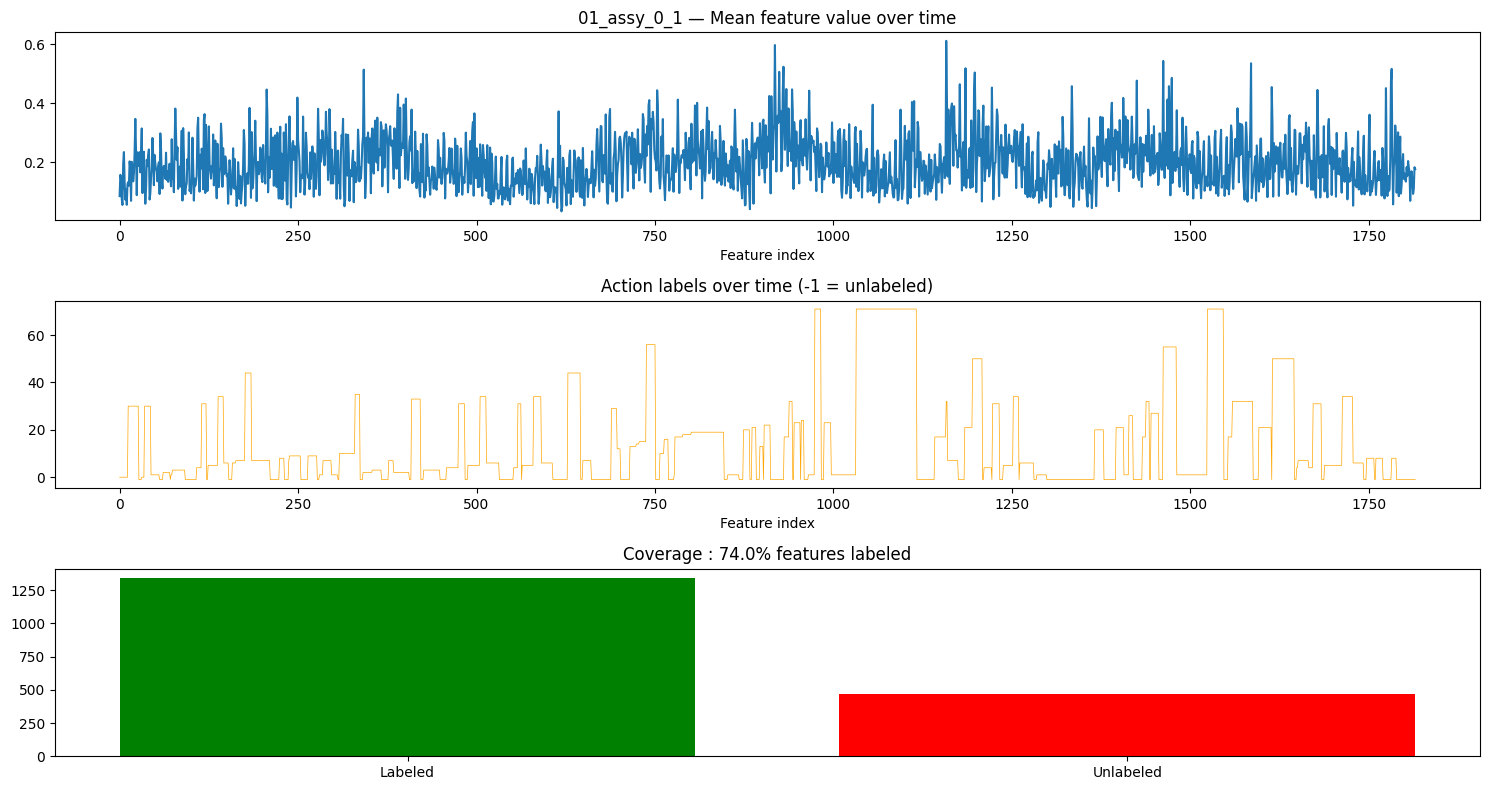

Coverage labels : 74.0%
Classes uniques : [ 0  1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24
 26 27 29 30 31 32 33 34 35 44 50 55 56 71]


In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Prendre 1 recording
rec = '01_assy_0_1'
arr = np.load(rec_to_file[rec])
sub = train_df[train_df['recording'] == rec].copy()
info = stride_map[rec]

# Construire label par feature index
labels_timeline = np.full(arr.shape[0], -1)  # -1 = pas de label
for _, row in sub.iterrows():
    i0, i1 = get_feature_indices_adaptive(
        row['frame_start'], row['frame_end'],
        info['f_min'], info['n_feats'], info['stride']
    )
    labels_timeline[i0:i1] = row['action_id']

# Plot
fig, axes = plt.subplots(3, 1, figsize=(15, 8))

# Features mean over time
axes[0].plot(arr.mean(axis=1))
axes[0].set_title(f'{rec} — Mean feature value over time')
axes[0].set_xlabel('Feature index')

# Labels timeline
axes[1].plot(labels_timeline, color='orange', linewidth=0.5)
axes[1].set_title('Action labels over time (-1 = unlabeled)')
axes[1].set_xlabel('Feature index')

# Coverage
covered = (labels_timeline >= 0).mean()
axes[2].bar(['Labeled', 'Unlabeled'], 
            [(labels_timeline >= 0).sum(), (labels_timeline < 0).sum()],
            color=['green', 'red'])
axes[2].set_title(f'Coverage : {covered:.1%} features labeled')

plt.tight_layout()
plt.savefig('/kaggle/working/sanity_check.png', dpi=100)
plt.show()

print(f'Coverage labels : {covered:.1%}')
print(f'Classes uniques : {np.unique(labels_timeline[labels_timeline>=0])}')

Features (bleu)  → signal riche et varié ✅
Labels (orange)  → segments discrets bien distribués ✅
Coverage 74%     → normal, 26% = transitions entre actions ✅
Classes uniques  → 38 classes présentes dans ce recording ✅
26% non labelisé = transitions entre actions — c'est attendu dans un dataset industriel. L'opérateur se déplace, repositionne ses mains entre deux actions.
✅ Compatibilité classes train/val
✅ Normalisation StandardScaler
✅ PCA → NON gardé
✅ Lissage → NON gardé  
✅ Features mortes → 0/2304
✅ Alignement temporel → stride_map par recording
✅ Class weights cappés à 10
✅ Segment stats analysés
✅ Sanity check visuel
✅ stride_map + scaler sauvegardés